In [13]:
# =============================================
# IMPORTY
# =============================================
import os
import sys
import math

import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f'✓ Device: {device}')
print(f'✓ PyTorch: {torch.__version__}')

_nb_dir = os.path.abspath('')
if os.path.basename(_nb_dir) in ('experiments', 'examples', 'train'):
    os.chdir(os.path.dirname(_nb_dir))
sys.path.insert(0, os.path.join(os.getcwd(), 'PFNs'))
print(f'✓ Working directory: {os.getcwd()}')

from pfns.train import train, MainConfig, OptimizerConfig, TransformerConfig, BatchShapeSamplerConfig
from pfns.model.encoders import EncoderConfig
from pfns.model.bar_distribution import BarDistributionConfig
from pfns.priors.prior import AdhocPriorConfig
from pfns.priors.fast_gp import get_batch as get_batch_for_gp

print('✓ PFNs načteny')

✓ Device: mps
✓ PyTorch: 2.10.0
✓ Working directory: /Users/ruslanguliev/VU_RG
✓ PFNs načteny


In [14]:
# =============================================
# NAČTENÍ MODELŮ
# =============================================
# DŮLEŽITÉ: get_batch_for_gp_random_hps musí být definována PŘED torch.load

def get_batch_for_gp_random_hps(batch_size, seq_len, num_features,
                                  device='cpu', hyperparameters=None, **kwargs):
    hps = {'lengthscale': 0.3, 'outputscale': 0.1, 'noise': 1.0}
    return get_batch_for_gp(batch_size, seq_len, num_features,
                             device=device, hyperparameters=hps, **kwargs)


def load_for_inference(checkpoint_path, device='cpu'):
    """
    Načte PFN checkpoint pro inferenci.
    Podporuje nový formát (klíč 'priors') i starý formát (klíč 'num_features').
    """
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    config = checkpoint['config']

    if 'num_features' in config:
        num_features     = config['num_features']
        max_dataset_size = config['max_dataset_size']
        criterion        = checkpoint['criterion']
        borders          = criterion.borders.tolist()
        nlayers          = config.get('nlayers', 6)
        get_batch_fn     = get_batch_for_gp
        prior_kwargs     = {'num_features': num_features,
                            'hyperparameters': config.get('hps', {})}
    else:
        num_features     = config['priors'][0]['prior_kwargs']['num_features']
        max_dataset_size = config['batch_shape_sampler']['max_seq_len']
        borders          = config['model']['criterion']['borders']
        nlayers          = config['model'].get('nlayers', 6)
        get_batch_fn     = get_batch_for_gp_random_hps
        prior_kwargs     = {'num_features': num_features, 'hyperparameters': {}}
        criterion        = None

    model_config = MainConfig(
        priors=[AdhocPriorConfig(
            get_batch_methods=[get_batch_fn],
            prior_kwargs=prior_kwargs
        )],
        optimizer=OptimizerConfig('adamw', lr=0.0003),
        model=TransformerConfig(
            criterion=BarDistributionConfig(full_support=True, borders=borders),
            emsize=512, nhead=8, nhid=1024, nlayers=nlayers,
            features_per_group=1, attention_between_features=False,
            encoder=EncoderConfig(
                constant_normalization_mean=0.5,
                constant_normalization_std=math.sqrt(1/12)
            )
        ),
        batch_shape_sampler=BatchShapeSamplerConfig(
            batch_size=2, max_seq_len=max_dataset_size,
            min_num_features=num_features, max_num_features=num_features
        ),
        epochs=1, steps_per_epoch=1, num_workers=0,
    )

    dummy_result = train(model_config, device=device, reusable_config=False)
    model = dummy_result['model']
    model.load_state_dict(checkpoint['model_state_dict'])
    if criterion is not None:
        model.criterion = criterion
    model.to(device)
    model.eval()

    epoch = checkpoint.get('epoch', '?')
    n_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f'  ✓ {os.path.basename(checkpoint_path)}: nlayers={nlayers}, epoch={epoch}, {n_params:.1f}M params')
    return model, epoch


MODEL_PATHS = {
    '1-layer': os.path.join('models', 'pfn_rand_hps_1layer.pth'),
    '2-layer': os.path.join('models', 'pfn_rand_hps_2layer.pth'),
    '4-layer': os.path.join('models', 'pfn_rand_hps_4layer.pth'),
    '6-layer': os.path.join('models', 'pfn_rand_hps_6layer.pth'),
    '8-layer': os.path.join('models', 'pfn_rand_hps_8layer.pth'),
}

print('Načítám modely...')
MODELS = {}
for name, path in MODEL_PATHS.items():
    if os.path.exists(path):
        MODELS[name], _ = load_for_inference(path, device)
    else:
        print(f'  ⚠ Nenalezeno: {path}')

# Evaluační HP — fixní, v rozsahu trénovací distribuce
# Evaluační HP — v rozsahu trénovací distribuce (ℓ∈[0.05,1], noise∈[0.001,0.1])
HPS = {'lengthscale': 0.3, 'noise': 0.01, 'outputscale': 1.0}  # střední obtížnost
# HPS = {'lengthscale': 0.1, 'noise': 0.5, 'outputscale': 1.0}  # těžká funkce: rychlé oscilace + velký šum

print(f'\n✓ Načteno {len(MODELS)} modelů: {list(MODELS.keys())}')
print(f'✓ Evaluační HP: {HPS}')

Načítám modely...
init dist
Not using distributed
ALL: Using device mps.
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_for_gp_random_hps (batch_size, seq_len, num_features, device='cpu', hyperparameters=None, **kwargs)
), num_features=1, hyperparameters={}), 'num_steps': 1, 'batch_shape_sampler_function': <bound method BatchShapeSamplerConfig.sample_batch_shape of BatchShapeSamplerConfig(batch_size=2, min_single_eval_pos=0, max_seq_len=100, min_num_features=1, max_num_features=1, fixed_num_test_instances=None, seed=42)>, 'num_workers': 0, 'persistent_workers': True, 'get_batch_kwargs': {'device': 'mps', 'n_targets_per_input': 1}, 'epoch_count': 0, 'importance_sampling_infos': None}
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_for_gp_random_hps (batch_size, seq_len, num_features, device='cpu', hyperparameters=None, **kwargs)
), num_features=1, hyperparameters={}), 'num_steps': 1,

## Experiment 5: Post-hoc lokalizace

### Motivace

PFN trénovaný na náhodných HP z wide prioru nemusí zvládnout lokálně hladké funkce — přiděluje pozornost i vzdáleným bodům, které nejsou informatívní. Nagler (2023) ukazuje, že stačí použít pouze $k_n$ nejbližších sousedů testovacího bodu:

$$k_n = \min\!\left\{500,\, \left\lceil n^{4/(d+4)} \right\rceil\right\}$$

Pro 1D ($d=1$): $k_n = \lceil n^{4/5} \rceil$. Pro $n=128$: $k_n \approx 80$.

### Co testujeme

**Post-hoc lokalizace** — model se netrénuje znovu, pouze při inferenci pro testovací bod $x^*$:
1. Spočítej vzdálenosti $|x^* - X_j|$ pro všechny trénovací body $j$
2. Vyber $k_n$ nejbližších sousedů
3. Spusť PFN pouze s těmito $k_n$ body jako kontextem

### Dvě otázky

**Q1 — Vliv $k$ na MSE** (při fixním $n$):  
Jak se MSE(PFN_k vs GP) mění s počtem sousedů $k$? Existuje optimum blízko $k_n$?

**Q2 — MSE dekompozice** (bias² + c/n):  
Snižuje lokalizace ireducibilní bias²? Srovnání plného kontextu vs. $k_n$ lokalizace přes různá $n$.

### Výsledné grafy

- **Graf 1**: MSE jako funkce $k$ při $n = 64$ — pro všechny modely, s vertikální čarou na $k_n$
- **Graf 2**: MSE dekompozice bias² + c/n — plný vs. lokalizovaný kontext, srovnání modelů

In [15]:
# =============================================
# GP UTILITY + LOKALIZOVANÁ INFERENCE
# =============================================

def kn_optimal(n, d=1):
    """
    Optimální k_n pro lokalizaci dle Nagler (2023):
        k_n = min(500, ceil(n^{4/(d+4)}))
    Pro 1D (d=1): k_n = ceil(n^{4/5})
    """
    return min(500, math.ceil(n ** (4.0 / (d + 4))))


def rbf_kernel(x1, x2, lengthscale, outputscale=1.0):
    dist_sq = (x1[:, None] - x2[None, :]) ** 2
    return outputscale * np.exp(-dist_sq / (2 * lengthscale**2))


def gp_exact_posterior_mean(tx, ty, te, ls, noise, osc=1.0):
    """Střední hodnota přesného GP posterioru."""
    K  = rbf_kernel(tx, tx, ls, osc) + noise * np.eye(len(tx))
    Ks = rbf_kernel(te, tx, ls, osc)
    try:
        L     = np.linalg.cholesky(K)
        alpha = np.linalg.solve(L.T, np.linalg.solve(L, ty))
    except np.linalg.LinAlgError:
        alpha = np.linalg.solve(K, ty)
    return Ks @ alpha


def pfn_predict(model, train_x, train_y, test_x, device):
    """
    Standardní PFN inference — model vidí celý kontext.
    train_x: (n, 1), train_y: (n,), test_x: (m, 1)
    Vrací: (m,) numpy array střední hodnoty.
    """
    with torch.no_grad():
        logits = model(
            train_x[None].to(device),
            train_y[None].to(device),
            test_x[None].to(device),
        )
    return model.criterion.mean(logits)[0].detach().cpu().numpy()


def pfn_predict_localized(model, train_x, train_y, test_x_single, k, device):
    """
    Post-hoc lokalizovaná PFN inference pro jeden testovací bod.
    Vybere k nejbližších trénovacích bodů k test_x_single a spustí
    model pouze s nimi jako kontextem.

    Args:
        train_x:       (n, 1) tensor — celý kontext
        train_y:       (n,)   tensor — trénovací hodnoty
        test_x_single: (1, 1) tensor — jediný testovací bod
        k:             počet nejbližších sousedů (ořízne se na min(k, n))

    Vrací: float — predikovaná střední hodnota
    """
    k      = min(k, train_x.shape[0])
    tx_np  = train_x.cpu().numpy().reshape(-1)
    te_val = float(test_x_single.cpu().numpy().reshape(-1)[0])
    idx    = np.argsort(np.abs(tx_np - te_val))[:k]

    with torch.no_grad():
        logits = model(
            train_x[idx][None].to(device),   # (1, k, 1)
            train_y[idx][None].to(device),    # (1, k)
            test_x_single[None].to(device),   # (1, 1, 1)
        )
    return float(model.criterion.mean(logits)[0].detach().cpu().numpy()[0])


print('✓ Utility funkce připraveny')
# Přehled k_n pro různá n:
print('\nk_n = ceil(n^{4/5}) pro různá n:')
for n in [5, 10, 20, 40, 64, 80, 100, 128]:
    print(f'  n={n:4d} → k_n={kn_optimal(n):3d}  (k_n/n = {kn_optimal(n)/n:.2f})')

✓ Utility funkce připraveny

k_n = ceil(n^{4/5}) pro různá n:
  n=   5 → k_n=  4  (k_n/n = 0.80)
  n=  10 → k_n=  7  (k_n/n = 0.70)
  n=  20 → k_n= 11  (k_n/n = 0.55)
  n=  40 → k_n= 20  (k_n/n = 0.50)
  n=  64 → k_n= 28  (k_n/n = 0.44)
  n=  80 → k_n= 34  (k_n/n = 0.42)
  n= 100 → k_n= 40  (k_n/n = 0.40)
  n= 128 → k_n= 49  (k_n/n = 0.38)


In [ ]:
# =============================================
# EXPERIMENTÁLNÍ FUNKCE
# =============================================

def generate_datasets(n_context, n_test, n_instances, hps):
    """
    Generuje sdílená data pro experimenty.
    Vrací: list of (train_x, train_y, test_x)
      train_x: (n_context, 1), train_y: (n_context,), test_x: (n_test, 1)
    """
    datasets = []
    for _ in range(n_instances):
        batch = get_batch_for_gp(
            batch_size=1, seq_len=n_context + n_test, num_features=1,
            device='cpu', hyperparameters=hps
        )
        datasets.append((
            batch.x[0, :n_context],
            batch.y[0, :n_context],
            batch.x[0, n_context:],
        ))
    return datasets


# ── Q1: MSE vs k při fixním n ─────────────────────────────────────────────

def compute_mse_vs_k(model, datasets, k_values, hps, device):
    """
    Pro pevné n (dané délkou datasetů) a různé k:
    MSE(PFN_k vs GP) průměrovaná přes instance a testovací body.

    Vrací: dict {k: (mean_mse, se)}  pro k in k_values + ['full']
    """
    ls, noise, osc = hps['lengthscale'], hps['noise'], hps.get('outputscale', 1.0)
    mse_acc = {'full': []}
    for k in k_values:
        mse_acc[k] = []

    for train_x, train_y, test_x in datasets:
        tx = train_x.numpy().reshape(-1)
        ty = train_y.numpy().reshape(-1)
        te = test_x.numpy().reshape(-1)
        try:
            gp_mu = gp_exact_posterior_mean(tx, ty, te, ls, noise, osc)
        except Exception:
            continue

        # Plný kontext
        try:
            pfn_full = pfn_predict(model, train_x, train_y, test_x, device)
            mse = float(np.mean((pfn_full - gp_mu)**2))
            if np.isfinite(mse) and mse < 100:
                mse_acc['full'].append(mse)
        except Exception:
            pass

        # Lokalizovaná inference pro každé k
        for k in k_values:
            preds = []
            ok = True
            for ti in range(test_x.shape[0]):
                try:
                    p = pfn_predict_localized(
                        model, train_x, train_y, test_x[ti:ti+1], k, device
                    )
                    preds.append(p)
                except Exception:
                    ok = False; break
            if ok and preds:
                mse = float(np.mean((np.array(preds) - gp_mu)**2))
                if np.isfinite(mse) and mse < 100:
                    mse_acc[k].append(mse)

    def _stats(lst):
        if not lst:
            return np.nan, np.nan
        return float(np.mean(lst)), float(np.std(lst) / np.sqrt(len(lst)))

    return {key: _stats(vals) for key, vals in mse_acc.items()}


def plot_mse_vs_k(all_results, k_values, n_fixed, hps):
    """
    Graf MSE(k) při fixním n pro všechny modely.
    Hvězdičky = standardní PFN bez lokalizace (k = n_fixed).
    Vertikální čára na k_n = ceil(n^{4/5}).
    """
    kn = kn_optimal(n_fixed)
    colors = plt.cm.tab10.colors
    fig, ax = plt.subplots(figsize=(9, 5))

    for i, (name, res) in enumerate(all_results.items()):
        c  = colors[i]
        xs = sorted(k_values)
        ys  = [res[k][0] for k in xs]
        ses = [res[k][1] for k in xs]
        ax.errorbar(xs, ys, yerr=ses, fmt='-o', color=c, lw=2, ms=6,
                    capsize=3, label=name)
        # Hvězdička = plný kontext (k = n_fixed)
        y_full, se_full = res['full']
        ax.errorbar([n_fixed], [y_full], yerr=[se_full], fmt='*',
                    color=c, ms=14, markeredgecolor='black', markeredgewidth=0.8)

    ax.axvline(kn, color='black', ls='--', lw=1.8, alpha=0.75,
               label=f'$k_n = \\lceil {n_fixed}^{{4/5}} \\rceil = {kn}$')
    ax.set_xlabel('Počet sousedů $k$', fontsize=12)
    ax.set_ylabel('MSE (PFN vs. GP posterior mean)', fontsize=12)
    ax.set_title(
        f'Q1: MSE vs. počet sousedů $k$  '
        f'($n={n_fixed}$, $\\ell={hps["lengthscale"]}$, $\\sigma^2={hps["noise"]}$)\n'
        f'Hvězdičky = plný kontext ($k=n$); čárkovaná čára = optimální $k_n$',
        fontsize=12
    )
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'\n{"Model":<12}  {"MSE_full":>10}  {"MSE_best":>10}  {"Best k":>7}  Zlepšení')
    print('-' * 55)
    for name, res in all_results.items():
        m_full   = res['full'][0]
        best_k   = min(k_values, key=lambda k: res[k][0] if np.isfinite(res[k][0]) else np.inf)
        m_best   = res[best_k][0]
        if np.isfinite(m_full) and np.isfinite(m_best) and m_full > 0:
            improvement = (m_full - m_best) / m_full * 100
            print(f'{name:<12}  {m_full:>10.5f}  {m_best:>10.5f}  {best_k:>7}  {improvement:>+.1f}%')


# ── Q2: MSE dekompozice bias² + c/n ─────────────────────────────────────────

def generate_decomp_datasets(n_values, n_test, n_instances, hps):
    """Generuje datasety pro různá n (pro MSE dekompozici)."""
    all_data = {}
    for n in n_values:
        data = []
        for _ in range(n_instances):
            batch = get_batch_for_gp(
                batch_size=1, seq_len=n + n_test, num_features=1,
                device='cpu', hyperparameters=hps
            )
            data.append((
                batch.x[0, :n],
                batch.y[0, :n],
                batch.x[0, n:],
            ))
        all_data[n] = data
    return all_data


def compute_mse_decomp_localized(model, all_data, hps, device):
    """
    Pro každé n: MSE pro plný kontext a k_n lokalizaci.
    Fituje bias² + c/n pro obě varianty.

    Vrací: (results_full, results_kn, fit_full, fit_kn)
      results_*: {n: (mean_mse, se)}
      fit_*:     (bias_sq, c, perr)
    """
    ls, noise, osc = hps['lengthscale'], hps['noise'], hps.get('outputscale', 1.0)
    results_full = {}
    results_kn   = {}

    for n in sorted(all_data.keys()):
        kn        = kn_optimal(n)
        full_list = []
        kn_list   = []

        for train_x, train_y, test_x in all_data[n]:
            tx = train_x.numpy().reshape(-1)
            ty = train_y.numpy().reshape(-1)
            te = test_x.numpy().reshape(-1)
            try:
                gp_mu = gp_exact_posterior_mean(tx, ty, te, ls, noise, osc)
            except Exception:
                continue

            # Plný kontext
            try:
                pfn_full = pfn_predict(model, train_x, train_y, test_x, device)
                mse = float(np.mean((pfn_full - gp_mu)**2))
                if np.isfinite(mse) and mse < 100:
                    full_list.append(mse)
            except Exception:
                pass

            # k_n lokalizace — po jednom testovacím bodu
            preds_kn = []
            ok = True
            for ti in range(test_x.shape[0]):
                try:
                    p = pfn_predict_localized(
                        model, train_x, train_y, test_x[ti:ti+1], kn, device
                    )
                    preds_kn.append(p)
                except Exception:
                    ok = False; break
            if ok and preds_kn:
                mse_kn = float(np.mean((np.array(preds_kn) - gp_mu)**2))
                if np.isfinite(mse_kn) and mse_kn < 100:
                    kn_list.append(mse_kn)

        results_full[n] = (
            np.mean(full_list) if full_list else np.nan,
            np.std(full_list) / np.sqrt(len(full_list)) if full_list else np.nan
        )
        results_kn[n] = (
            np.mean(kn_list)   if kn_list   else np.nan,
            np.std(kn_list)   / np.sqrt(len(kn_list))   if kn_list   else np.nan
        )
        print(f'  n={n:3d} (k_n={kn:3d}):'
              f'  MSE_full={results_full[n][0]:.5f},'
              f'  MSE_kn={results_kn[n][0]:.5f}')

    def _fit(results):
        ns   = np.array(sorted(results.keys()), dtype=float)
        mses = np.array([results[int(n)][0] for n in ns])
        valid = ~np.isnan(mses)
        if valid.sum() < 2:
            return 0.0, 1.0, np.array([0.0, 0.0])
        try:
            popt, pcov = curve_fit(
                lambda n, b, c: b + c / n, ns[valid], mses[valid],
                p0=[float(mses[valid].min()), 1.0],
                bounds=([0, 0], [np.inf, np.inf]), maxfev=5000
            )
            return float(popt[0]), float(popt[1]), np.sqrt(np.diag(pcov))
        except Exception:
            return 0.0, 1.0, np.array([0.0, 0.0])

    return results_full, results_kn, _fit(results_full), _fit(results_kn)


def plot_mse_decomp_localized(all_model_results, hps, title=''):
    """
    Graf MSE(n) pro všechny modely, porovnání plného kontextu vs. k_n lokalizace.
    Kruhové body + plná čára = full; trojúhelníkové body + čárkovaná čára = k_n.
    Horizontální tečkované čáry = asymptotické bias².

    all_model_results: dict {model_name: (results_full, results_kn, fit_full, fit_kn)}
    """
    colors = plt.cm.tab10.colors
    fig, ax = plt.subplots(figsize=(11, 6))

    for i, (name, (r_full, r_kn, fit_full, fit_kn)) in enumerate(all_model_results.items()):
        c  = colors[i]
        ns = np.array(sorted(r_full.keys()), dtype=float)

        mses_full = np.array([r_full[int(n)][0] for n in ns])
        stes_full = np.array([r_full[int(n)][1] for n in ns])
        mses_kn   = np.array([r_kn[int(n)][0]   for n in ns])
        stes_kn   = np.array([r_kn[int(n)][1]   for n in ns])

        b_full, c_full, _ = fit_full
        b_kn,   c_kn,   _ = fit_kn
        n_fine = np.linspace(ns.min(), ns.max() * 1.25, 300)

        ax.errorbar(ns, mses_full, yerr=stes_full, fmt='o',
                    color=c, ms=7, capsize=3, zorder=3)
        ax.errorbar(ns, mses_kn,   yerr=stes_kn,   fmt='^',
                    color=c, ms=7, capsize=3, zorder=3)
        ax.plot(n_fine, b_full + c_full / n_fine, '-',  color=c, lw=2.2,
                label=f'{name} full   (bias²={b_full:.4f})')
        ax.plot(n_fine, b_kn   + c_kn   / n_fine, '--', color=c, lw=2.2,
                label=f'{name} $k_n$  (bias²={b_kn:.4f})')
        ax.axhline(b_full, color=c, ls=':', alpha=0.35, lw=1.2)
        ax.axhline(b_kn,   color=c, ls=':', alpha=0.35, lw=1.2)

    ax.set_xlabel('Počet kontextových bodů $n$', fontsize=12)
    ax.set_ylabel('MSE (PFN vs. GP posterior mean)', fontsize=12)
    _title = title or (
        f'Q2: MSE dekompozice — plný kontext (○) vs. $k_n$ lokalizace (△)\n'
        f'$\\ell={hps["lengthscale"]}$, $\\sigma^2={hps["noise"]}$,  fit: bias² + c/n'
    )
    ax.set_title(_title, fontsize=13)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=9, ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'\n{"Model":<12}  {"bias²_full":>12}  {"bias²_kn":>10}  {"Relativní změna bias²":>14}')
    print('-' * 56)
    for name, (_, _, fit_full, fit_kn) in all_model_results.items():
        bf = fit_full[0]
        bk = fit_kn[0]
        delta = (bf - bk) / max(bf, 1e-10) * 100
        print(f'{name:<12}  {bf:>12.5f}  {bk:>10.5f}  {delta:>+13.1f}%')


print('✓ Experimentální funkce připraveny')

✓ Experimentální funkce připraveny


n_fixed = 64,  k_n = 28
k_values = [2, 7, 12, 16, 21, 26, 28, 31, 35, 40, 45, 50, 54, 59, 64]
Generuji datasety (n=64, n_test=5, inst=100)...

Počítám MSE vs k pro každý model...
  1-layer...
  2-layer...
  4-layer...
  6-layer...
  8-layer...


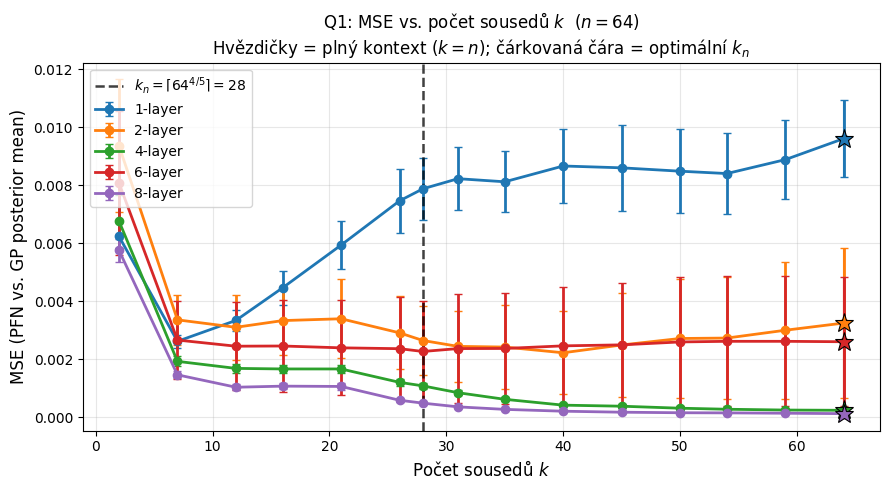


Model           MSE_full    MSE_best   Best k  Zlepšení
-------------------------------------------------------
1-layer          0.00962     0.00263        7  +72.7%
2-layer          0.00326     0.00223       40  +31.5%
4-layer          0.00025     0.00025       64  +0.0%
6-layer          0.00261     0.00228       28  +12.8%
8-layer          0.00013     0.00013       64  +0.0%


In [17]:
# =============================================
# SPUŠTĚNÍ Q1: MSE vs k při fixním n
# =============================================

N_FIXED      = 64        # počet kontextových bodů
N_TEST_Q1    = 5         # testovacích bodů na instanci
N_INST_Q1    = 100       # počet instancí

kn = kn_optimal(N_FIXED)
# k_values: rovnoměrně rozmístěné od 2 do N_FIXED, vždy zahrnuje k_n
K_VALUES = sorted(set(
    [kn] + [int(round(x)) for x in np.linspace(2, N_FIXED, 14)]
))

print(f'n_fixed = {N_FIXED},  k_n = {kn}')
print(f'k_values = {K_VALUES}')
print(f'Generuji datasety (n={N_FIXED}, n_test={N_TEST_Q1}, inst={N_INST_Q1})...')

datasets_q1 = generate_datasets(N_FIXED, N_TEST_Q1, N_INST_Q1, HPS)

print('\nPočítám MSE vs k pro každý model...')
q1_results = {}
for name, model in MODELS.items():
    print(f'  {name}...')
    q1_results[name] = compute_mse_vs_k(model, datasets_q1, K_VALUES, HPS, device)

plot_mse_vs_k(q1_results, K_VALUES, N_FIXED, HPS)

n_values = [5, 10, 20, 40, 64, 100, 128]
k_n pro každé n: [(5, 4), (10, 7), (20, 11), (40, 20), (64, 28), (100, 40), (128, 49)]

Generuji datasety pro MSE dekompozici...
✓ 700 instancí celkem

Počítám MSE dekompozici pro každý model...

--- 1-layer ---
  n=  5 (k_n=  4):  MSE_full=0.05928,  MSE_kn=0.05718
  n= 10 (k_n=  7):  MSE_full=0.03074,  MSE_kn=0.02672
  n= 20 (k_n= 11):  MSE_full=0.01947,  MSE_kn=0.01585
  n= 40 (k_n= 20):  MSE_full=0.01013,  MSE_kn=0.00788
  n= 64 (k_n= 28):  MSE_full=0.00742,  MSE_kn=0.00634
  n=100 (k_n= 40):  MSE_full=0.00844,  MSE_kn=0.00829
  n=128 (k_n= 49):  MSE_full=0.00879,  MSE_kn=0.00578

--- 2-layer ---
  n=  5 (k_n=  4):  MSE_full=0.04000,  MSE_kn=0.04130
  n= 10 (k_n=  7):  MSE_full=0.02241,  MSE_kn=0.01913
  n= 20 (k_n= 11):  MSE_full=0.00445,  MSE_kn=0.00519
  n= 40 (k_n= 20):  MSE_full=0.00217,  MSE_kn=0.00329
  n= 64 (k_n= 28):  MSE_full=0.00682,  MSE_kn=0.00290
  n=100 (k_n= 40):  MSE_full=0.01422,  MSE_kn=0.00839
  n=128 (k_n= 49):  MSE_full

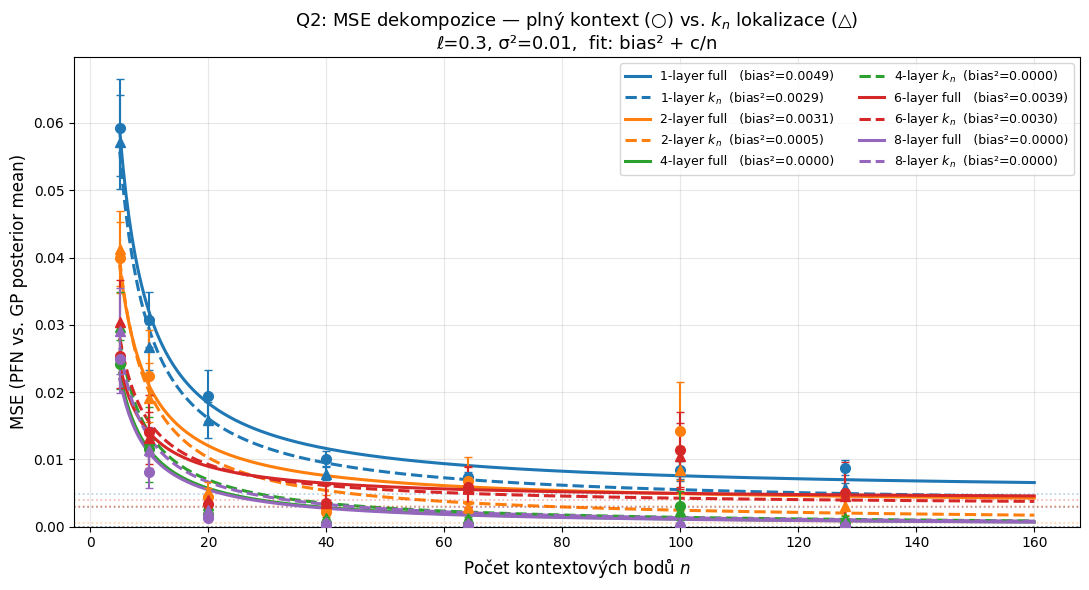


Model           bias²_full    bias²_kn     Změna bias²
--------------------------------------------------------
1-layer            0.00488     0.00286          +41.3%
2-layer            0.00314     0.00050          +84.2%
4-layer            0.00000     0.00000         -553.4%
6-layer            0.00394     0.00298          +24.4%
8-layer            0.00000     0.00000          -35.3%


In [18]:
# =============================================
# SPUŠTĚNÍ Q2: MSE dekompozice bias² + c/n
# =============================================

N_VALUES    = [5, 10, 20, 40, 64, 100, 128]
N_TEST_Q2   = 5
N_INST_Q2   = 100

print(f'n_values = {N_VALUES}')
print(f'k_n pro každé n: {[(n, kn_optimal(n)) for n in N_VALUES]}')
print(f'\nGeneruji datasety pro MSE dekompozici...')
decomp_data = generate_decomp_datasets(N_VALUES, N_TEST_Q2, N_INST_Q2, HPS)
print(f'✓ {sum(len(v) for v in decomp_data.values())} instancí celkem')

print('\nPočítám MSE dekompozici pro každý model...')
all_decomp_results = {}
for name, model in MODELS.items():
    print(f'\n--- {name} ---')
    all_decomp_results[name] = compute_mse_decomp_localized(
        model, decomp_data, HPS, device
    )

plot_mse_decomp_localized(all_decomp_results, HPS)

## Interpretace výsledků

### Q1 — MSE vs k (při fixním n)

**Osa X (log):** počet nejbližších sousedů $k$  
**Osa Y:** MSE(PFN_k vs GP posterior mean)  
**Hvězdičky:** standardní PFN s celým kontextem ($k = n$)  
**Čárkovaná čára:** optimální $k_n = \lceil n^{4/5} \rceil$

| Pozorování | Závěr |
|---|---|
| MSE klesá s rostoucím $k$, pak roste | Optimum existuje blízko $k_n$ |
| MSE monotónně klesá k MSE_full | Víc kontextu vždy pomáhá (model netrpí přetížením) |
| Minimum je v $k \ll n$ | Lokalizace redukuje šum od vzdálených bodů |
| Minimum je u $k = n$ | Model sám efektivně ignoruje vzdálené body |

---

### Q2 — MSE dekompozice

**Plná čára (○):** plný kontext — MSE(n) ≈ bias²_full + c_full/n  
**Čárkovaná čára (△):** k_n lokalizace — MSE(n) ≈ bias²_kn + c_kn/n  
**Vodorovné tečky:** asymptotické bias² (pro n → ∞)

| Pozorování | Závěr |
|---|---|
| bias²_kn < bias²_full | Lokalizace snižuje ireducibilní chybu — potvrzuje Nagler teorém |
| c_kn > c_full | Menší efektivní kontext zvyšuje varianční člen (kompromis) |
| Pro malé n MSE_kn > MSE_full | Pro malé n je k_n ≈ n — lokalizace nepomáhá |
| Vícevrstvé modely mají nižší bias² | Hloubka pomáhá i bez lokalizace |

### Nagler (2023) — teorie

Pro $k_n = \lceil n^{4/(d+4)} \rceil$ platí:
- $k_n \to \infty$: lokalizovaný odhad konverguje k pravdě
- $k_n / n \to 0$: podíl použitých bodů klesá (pro 1D: $n^{-1/5} \to 0$)
- Bias² lokalizovaného odhadu $\to 0$ pro $n \to \infty$ — na rozdíl od plného PFN,
  který může mít nenulový bias² daný omezenou kapacitou modelu.